In [6]:
%load_ext autoreload
%autoreload 2


In [11]:
importlib.reload(pipeline_utils)

NameError: name 'importlib' is not defined

In [12]:
from pipeline_utils import (
    pipe,
    fit_and_predict,
    compare_models_with_timing,
    train_pred_test_reports,
    tune_model,
    compare_models,
)


In [5]:
import inspect
print(inspect.signature(compare_models))

(models: dict, num_f, cat_f, X_train, y_train, X_test, y_test, cv: int = 5, scoring=('accuracy', 'f1', 'roc_auc'), show_confusion_matrix: bool = True, show_feature_importance: bool = True, show_correct_incorrect_analysis: bool = True, top_n_diff: int = 5)


[LogisticRegression]


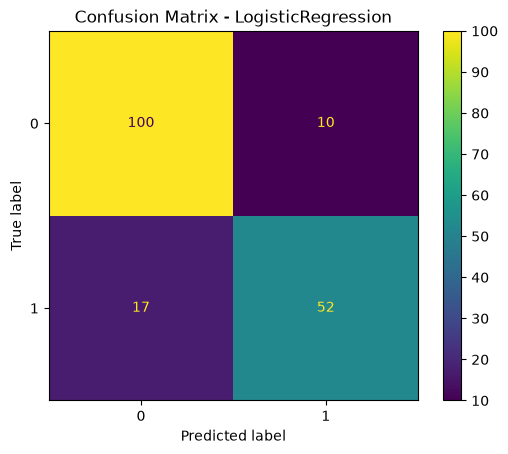

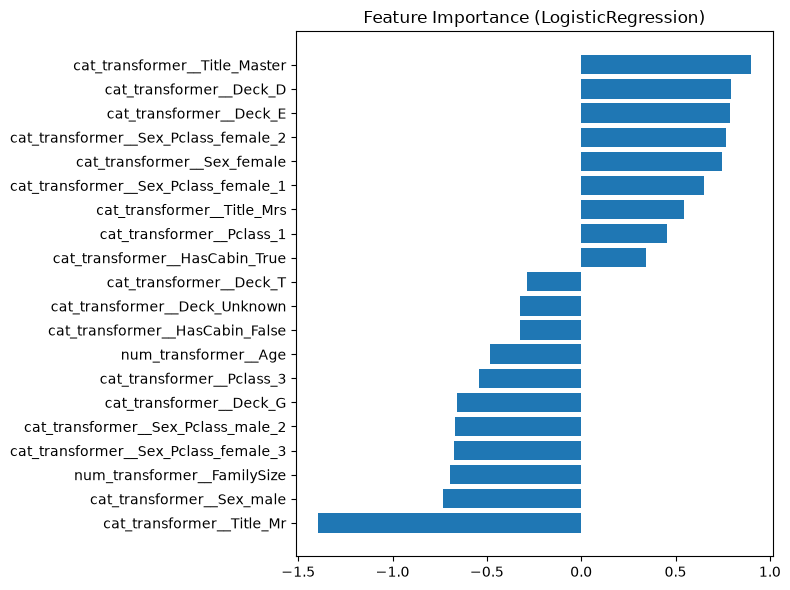


[LogisticRegression] 정답/오답 그룹 간 수치형 피처 평균 차이 (상위 5개)
_correct    incorrect_mean  correct_mean  abs_diff
Fare             28.168363     34.721626  6.553263
Age              30.851852     28.527961  2.323891
FamilySize        1.518519      2.072368  0.553850

[LogisticRegression] 정답/오답 그룹 간 범주형 피처 최빈값
       feature      group most_common_value  proportion
0       Pclass    correct                 3      0.5658
1       Pclass  incorrect                 3      0.5185
2          Sex    correct              male      0.6645
3          Sex  incorrect              male      0.6296
4        Title    correct                Mr      0.5855
5        Title  incorrect                Mr      0.5926
6      IsAlone    correct              True      0.5592
7      IsAlone  incorrect              True      0.6667
8         Deck    correct           Unknown      0.7632
9         Deck  incorrect           Unknown      0.7037
10    HasCabin    correct             False      0.7632
11    HasCabin  incorrect 

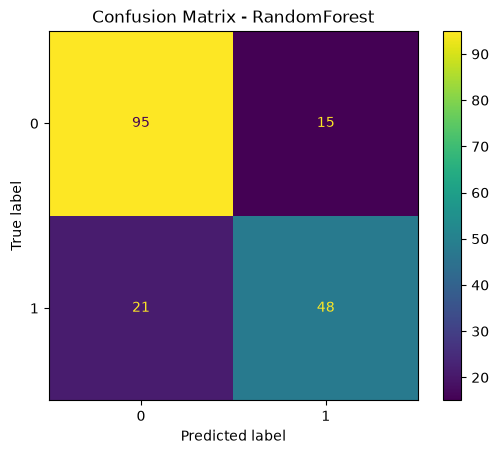

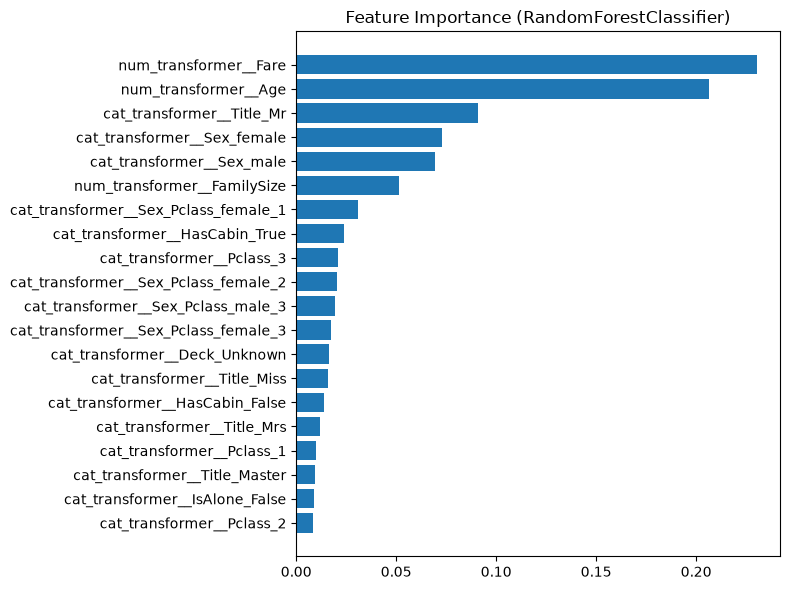


[RandomForest] 정답/오답 그룹 간 수치형 피처 평균 차이 (상위 5개)
_correct    incorrect_mean  correct_mean   abs_diff
Fare             45.963078     30.654281  15.308797
Age              33.111111     27.812937   5.298174
FamilySize        1.694444      2.062937   0.368493

[RandomForest] 정답/오답 그룹 간 범주형 피처 최빈값
       feature      group most_common_value  proportion
0       Pclass    correct                 3      0.5804
1       Pclass  incorrect                 3      0.4722
2          Sex    correct              male      0.6573
3          Sex  incorrect              male      0.6667
4        Title    correct                Mr      0.5874
5        Title  incorrect                Mr      0.5833
6      IsAlone    correct              True      0.5874
7      IsAlone  incorrect              True      0.5278
8         Deck    correct           Unknown      0.7902
9         Deck  incorrect           Unknown      0.6111
10    HasCabin    correct             False      0.7902
11    HasCabin  incorrect         

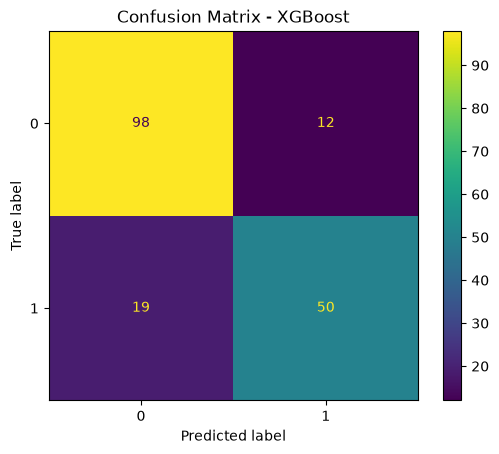

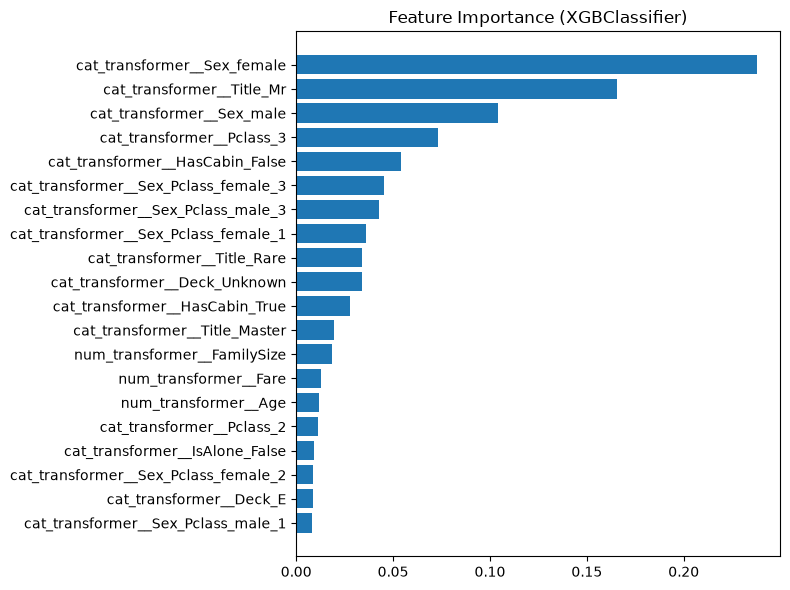


[XGBoost] 정답/오답 그룹 간 수치형 피처 평균 차이 (상위 5개)
_correct    incorrect_mean  correct_mean   abs_diff
Fare             48.965726     30.542537  18.423189
Age              32.387097     28.143581   4.243516
FamilySize        1.677419      2.054054   0.376635

[XGBoost] 정답/오답 그룹 간 범주형 피처 최빈값
       feature      group most_common_value  proportion
0       Pclass    correct                 3      0.5743
1       Pclass  incorrect                 3      0.4839
2          Sex    correct              male      0.6554
3          Sex  incorrect              male      0.6774
4        Title    correct                Mr      0.5878
5        Title  incorrect                Mr      0.5806
6      IsAlone    correct              True      0.5811
7      IsAlone  incorrect              True      0.5484
8         Deck    correct           Unknown      0.7838
9         Deck  incorrect           Unknown      0.6129
10    HasCabin    correct             False      0.7838
11    HasCabin  incorrect             False 

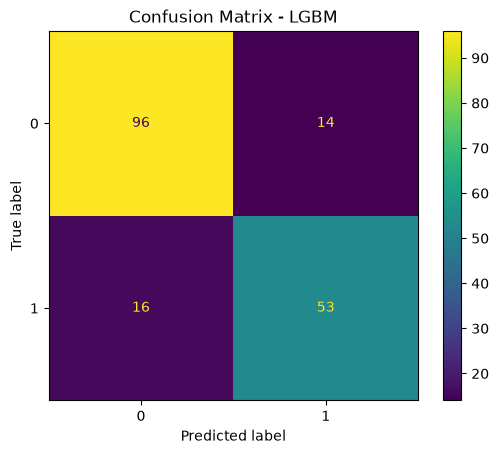

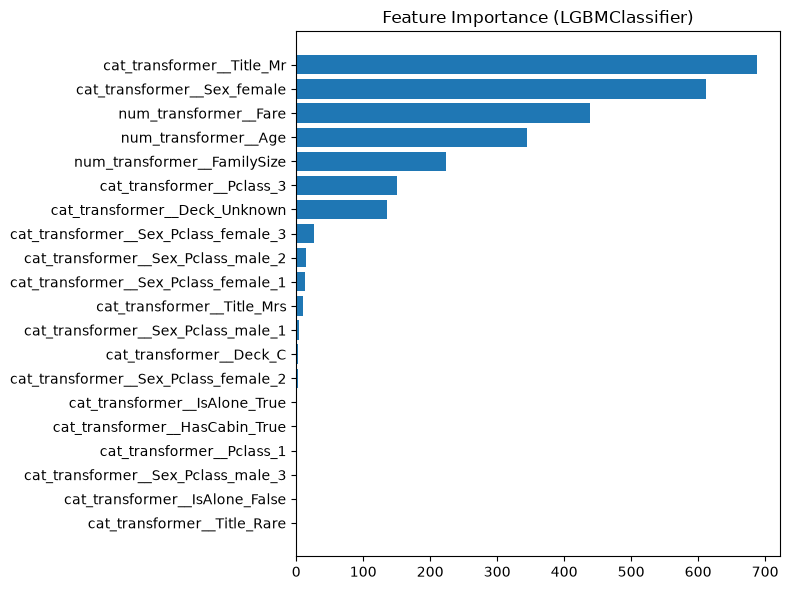


[LGBM] 정답/오답 그룹 간 수치형 피처 평균 차이 (상위 5개)
_correct    incorrect_mean  correct_mean  abs_diff
Age              32.666667     28.115772  4.550895
Fare             34.469443     33.584897  0.884546
FamilySize        1.700000      2.046980  0.346980

[LGBM] 정답/오답 그룹 간 범주형 피처 최빈값
       feature      group most_common_value  proportion
0       Pclass    correct                 3      0.5772
1       Pclass  incorrect                 3      0.4667
2          Sex    correct              male      0.6510
3          Sex  incorrect              male      0.7000
4        Title    correct                Mr      0.5839
5        Title  incorrect                Mr      0.6000
6      IsAlone    correct              True      0.5772
7      IsAlone  incorrect              True      0.5667
8         Deck    correct           Unknown      0.7852
9         Deck  incorrect           Unknown      0.6000
10    HasCabin    correct             False      0.7852
11    HasCabin  incorrect             False      0.600

,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,LogisticRegression,0.830119,0.025579,0.767456,0.029773,0.873981,0.013204
2,XGBoost,0.827312,0.025693,0.757937,0.038609,0.876196,0.013916
3,LGBM,0.823106,0.023069,0.755880,0.031693,0.882963,0.012687
1,RandomForest,0.807663,0.027690,0.743882,0.036687,0.861181,0.023815


,model,fit_time_sec,predict_time_sec
0,LogisticRegression,0.041834,0.009901
1,RandomForest,0.156172,0.010867
2,XGBoost,0.817507,0.012865
3,LGBM,0.133681,0.011128


In [15]:

"""
=================
pipeline_utils.py의 함수들을 실제로 사용하는 예시 흐름.

전체 흐름: 데이터 분리 -> 여러 모델 스크리닝 -> 상위 모델 튜닝 -> 최종 학습/평가
"""

import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from pipeline_utils import (
    pipe,
    fit_and_predict,
    compare_models_with_timing,
    train_pred_test_reports,
    tune_model,
    compare_models,
)

# ------------------------------------------------------------------
# 0. 데이터 준비 (예시 - 실제 데이터로 교체)
# ------------------------------------------------------------------
###################################################################
## 타이타닉 features engineering
###################################################################
def add_features(df):
    """Name, SibSp/Parch, Cabin으로부터 파생 변수를 만듭니다."""
    df = df.copy()

    # Name에서 호칭 추출: "Braund, Mr. Owen Harris" -> "Mr"
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    # - Age 결측값: Title 기준 평균값으로 채우기
    df['Age'] = df.groupby('Title')['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    # Title 모수가 적은 Title  Rare로 통일 :
    common = ["Mr", "Mrs", "Miss", "Master"]
    df["Title"] = df["Title"].where(df["Title"].isin(common), "Rare")

    # 가족 규모와 혼자 탑승 여부
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1)

    # - Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 unknown 처리(기존에 없는 값)
    df['Deck'] = df['Cabin'].str[0]
    df['Deck'] = df['Deck'].fillna('Unknown')

    # Cabin은 77%가 결측이라 값을 채우는 대신, 정보가 있는지 여부를 변수로 씁니다.
    df["HasCabin"] = df["Cabin"].notnull()

    ### 성별과 객실 등급
    df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)

    # - Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df


train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
train_fe = add_features(train_df)
test_fe = add_features(test_df)


num_features = ['Age',  'Fare', 'FamilySize'] #'SibSp', 'Parch',
cat_features = ['Pclass', 'Sex', 'Title', 'IsAlone', 'Deck', 'HasCabin', 'Sex_Pclass'] #, 'Embarked'
FEATURES = num_features + cat_features
train_fe[FEATURES]
# df = pd.read_csv("your_data.csv")
# X = df.drop(columns=['target'])
# y = df['target']

X = train_fe[FEATURES]
y = train_fe['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------------
# 1. 여러 모델 1차 스크리닝 (cross-validation)
# ------------------------------------------------------------------
candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    
    'RandomForest': RandomForestClassifier(random_state=42),
    #'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.8, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss', feature_types=None,
              feature_weights=None, gamma=0.2087,
              grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=0.0422, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3,  monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None),
    'LGBM': LGBMClassifier( n_estimators=1000, num_leaves=25, min_child_samples=33,
                        random_state=42, 
                        reg_alpha=1.125,
                        reg_lambda=4.369,
                        verbose=-1,           # Warning/Info 숨김
                        force_row_wise=True,  # 위 Info 로그 방지 (선택)
                        importance_type='gain', #'split'(기본값, 분할 횟수 카운트)이 아니라 'gain'(실제 손실 감소 기여도) 기준으로
                        ),    
}

screening_summary, screening_details = compare_models(
    models=candidate_models,
    num_f=num_features,
    cat_f=cat_features,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=5,
    scoring=['accuracy', 'f1', 'roc_auc'],
    show_confusion_matrix=True,       # 모델별 confusion matrix 시각화
    show_feature_importance=True,     # 모델별 feature importance 시각화
    show_correct_incorrect_analysis=True,  # 정답/오답 그룹 간 피처 차이 분석
    top_n_diff=5,
)
display(screening_summary)

# 특정 모델의 상세 결과(정오답 분석, confusion matrix 등)만 다시 꺼내보고 싶다면:
# screening_details['RandomForest']['correct_incorrect_analysis']

# 학습/예측 속도까지 함께 보고 싶다면:
timing_result = compare_models_with_timing(
    candidate_models, num_features, cat_features, X_train, y_train, X_test, y_test
)
display(timing_result)

# # ------------------------------------------------------------------
# # 2. 상위 후보 하이퍼파라미터 튜닝 (예: XGBoost가 1등이라고 가정)
# # ------------------------------------------------------------------
# param_grid = {
#     'estimator__n_estimators': [200, 400],
#     'estimator__max_depth': [3, 5, 7],
#     'estimator__learning_rate': [0.05, 0.1],
# }

# best_pipeline, best_params, best_score = tune_model(
#     model=XGBClassifier(random_state=42, eval_metric='logloss'),
#     param_grid=param_grid,
#     num_f=num_features,
#     cat_f=cat_features,
#     X=X_train,
#     y=y_train,
#     cv=5,
#     scoring='roc_auc',
# )
# print("Best params:", best_params)
# print("Best CV score:", best_score)

# # ------------------------------------------------------------------
# # 3. 최종 모델 학습 + 예측 (튜닝된 파라미터로 새 파이프라인 조립)
# # ------------------------------------------------------------------
# final_model = XGBClassifier(random_state=42, eval_metric='logloss', **{
#     k.replace('estimator__', ''): v for k, v in best_params.items()
# })
# final_pipeline = pipe(model=final_model, num_f=num_features, cat_f=cat_features, X=X_train)

# fitted_pipeline, preds, probs, train_preds, train_probs = fit_and_predict(
#     final_pipeline, X_train, y_train, X_test
# )

# # ------------------------------------------------------------------
# # 4. 최종 리포트 및 시각화
# # ------------------------------------------------------------------
# summary = train_pred_test_reports(
#     fitted_pipeline,
#     X_train, y_train, X_test, y_test,
#     preds, probs, train_preds, train_probs,
#     cv=5,
# )
# print(summary)

Best model:  LogisticRegression(C=0.3, class_weight='balanced', max_iter=1000,
                   solver='liblinear')
Best params: {'estimator__C': 0.3, 'estimator__class_weight': 'balanced', 'estimator__l1_ratio': 0.0}
Best CV score: 0.8769272400071774
Estimator: LogisticRegression

[Overfitting Check]
Train ROC AUC : 0.8851
Test  ROC AUC : 0.8775
Train Accuracy: 0.8343
Test  Accuracy: 0.8268

[Cross-Validation]
CV roc_auc mean: 0.8766 (+/- 0.0113)
Avg fit time  : 0.0278s (+/- 0.0038)
Avg score time: 0.0184s (+/- 0.0080)

[Feature Importance]


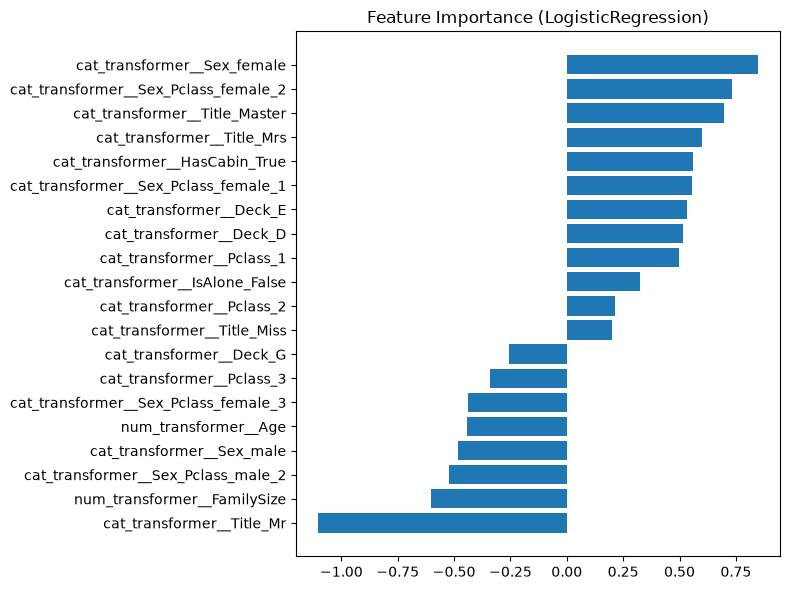


[Confusion Matrix]


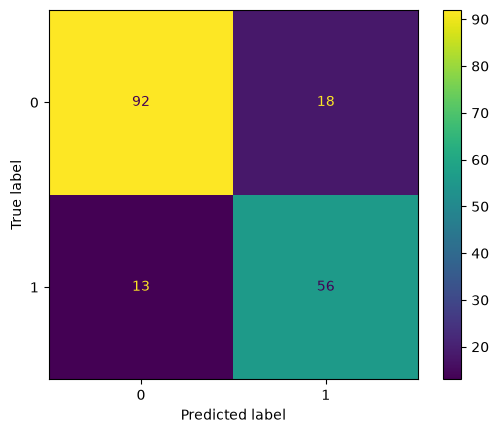


[Classification Report]
              precision    recall  f1-score   support

           0     0.8762    0.8364    0.8558       110
           1     0.7568    0.8116    0.7832        69

    accuracy                         0.8268       179
   macro avg     0.8165    0.8240    0.8195       179
weighted avg     0.8302    0.8268    0.8278       179

{'train_accuracy': 0.8342696629213483, 'test_accuracy': 0.8268156424581006, 'cv_score_mean': np.float64(0.876585024751169), 'cv_score_std': np.float64(0.011346736618292708)}


In [25]:

# ------------------------------------------------------------------
# 2. 상위 후보 하이퍼파라미터 튜닝 
# ------------------------------------------------------------------
# XGBoost param_grid
# param_grid = {
#     'estimator__n_estimators': [200, 400],
#     'estimator__max_depth': [3, 5, 7],
#     'estimator__learning_rate': [0.05, 0.1],
# }
# LogisticRegression param_grid
param_grid = {
    'estimator__C': [0.01, 0.05, 0.1, 0.3, 0.5, 1, 3, 5, 10],
    'estimator__l1_ratio': [0.0, 1.0],          # 0.0=L2, 1.0=L1 (solver='liblinear'는 elasticnet 불가)
    'estimator__class_weight': [None, 'balanced']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_pipeline, best_params, best_score = tune_model(
    #model=XGBClassifier(random_state=42, eval_metric='logloss'), #XGBoost
    model= LogisticRegression(solver='liblinear', max_iter=1000),
    param_grid=param_grid,
    num_f=num_features,
    cat_f=cat_features,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring='roc_auc',
)
final_model = best_pipeline.named_steps['estimator']
print("Best model: ", final_model)
print("Best params:", best_params)
print("Best CV score:", best_score)

# ------------------------------------------------------------------
# 3. 최종 모델 학습 + 예측 (튜닝된 파라미터로 새 파이프라인 조립)
# ------------------------------------------------------------------
# final_model = XGBClassifier(random_state=42, eval_metric='logloss', **{
#     k.replace('estimator__', ''): v for k, v in best_params.items()
# })#

final_pipeline = pipe(model=final_model, num_f=num_features, cat_f=cat_features, X=X_train)

fitted_pipeline, preds, probs, train_preds, train_probs = fit_and_predict(
    final_pipeline, X_train, y_train, X_test
)

# ------------------------------------------------------------------
# 4. 최종 리포트 및 시각화
# ------------------------------------------------------------------
summary = train_pred_test_reports(
    fitted_pipeline,
    X_train, y_train, X_test, y_test,
    preds, probs, train_preds, train_probs,
    cv=5,
)
print(summary)